In [6]:
!pip install pandas numpy scikit-learn xgboost lightgbm fairlearn shap scipy optuna category_encoders

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, KBinsDiscretizer, PolynomialFeatures, FunctionTransformer
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Fairness
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference

# Explicabilidad
import shap

# Cross-validation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import f1_score
from sklearn.calibration import CalibratedClassifierCV
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

In [44]:
def load_and_clean_compas(path):
    df = pd.read_csv(path)
    
    # Filtrado ProPublica
    df_clean = df[
        (df['days_b_screening_arrest'] <= 30) & 
        (df['days_b_screening_arrest'] >= -30) &
        (df['is_recid'] != -1) &
        (df['c_charge_degree'] != 'O') &
        (df['score_text'] != 'N/A')
    ].copy()
    
    # Feature Engineering
    df_clean['jail_days'] = (
        pd.to_datetime(df_clean['c_jail_out']) - pd.to_datetime(df_clean['c_jail_in'])
    ).dt.total_seconds() / 86400.0
    df_clean['jail_days'] = df_clean['jail_days'].fillna(0).clip(lower=0)
    
    df_clean['total_juv'] = df_clean['juv_fel_count'] + df_clean['juv_misd_count'] + df_clean['juv_other_count']
    df_clean['has_juv_record'] = (df_clean['total_juv'] > 0).astype(int)
    df_clean['log_priors'] = np.log1p(df_clean['priors_count'])
    df_clean['age_priors'] = df_clean['age'] * df_clean['priors_count']
    
    # Agrupar cargos poco frecuentes en 'Other'
    charge_counts = df_clean['c_charge_desc'].value_counts()
    rare_charges = charge_counts[charge_counts < 20].index
    df_clean['charge_group'] = df_clean['c_charge_desc'].where(
        ~df_clean['c_charge_desc'].isin(rare_charges), 'Other'
    )
    
    features = [
        # Originales
        'sex', 'age', 'race',
        'juv_fel_count', 'juv_misd_count', 'juv_other_count',
        'priors_count', 'c_charge_degree',
        # Nuevas del dataset
        'days_b_screening_arrest', 'c_days_from_compas',
        'age_cat', 'charge_group',
        # Engineered
        'jail_days', 'total_juv', 'has_juv_record',
        'log_priors', 'age_priors',
    ]
    target = 'two_year_recid'
    
    df_final = df_clean[features + [target]].dropna()
    X = df_final[features].copy()
    y = df_final[target].copy()
    
    return X, y

#### **4.1 - Preprocesamiento**

In [45]:
X, y = load_and_clean_compas('./dataset/compas-scores-two-years.csv')
print(f'Dataset shape: {X.shape}')
print(f'Features: {list(X.columns)}')
print(f'Target distribution:\n{y.value_counts(normalize=True)}')

stratify_cols = y.astype(str) + X['race'].astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=stratify_cols
)

numeric_features = [
    'age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count',
    'days_b_screening_arrest', 'c_days_from_compas',
    'jail_days', 'total_juv', 'has_juv_record', 'log_priors', 'age_priors'
]
categorical_features = ['sex', 'race', 'c_charge_degree', 'age_cat', 'charge_group']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, interaction_only=False, include_bias=False))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_transformed = preprocessor.fit_transform(X_train, y_train)
print(f'\nFeatures tras preprocesamiento: {X_transformed.shape[1]}')

Dataset shape: (6167, 17)
Features: ['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree', 'days_b_screening_arrest', 'c_days_from_compas', 'age_cat', 'charge_group', 'jail_days', 'total_juv', 'has_juv_record', 'log_priors', 'age_priors']
Target distribution:
two_year_recid
0    0.544511
1    0.455489
Name: proportion, dtype: float64

Features tras preprocesamiento: 152


#### **4.2 - Modelo baseline**

##### Construcción del Pipeline

In [46]:
# 1. Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42))
])

# 2. Entrenamiento
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

##### Rendimiento del modelo

In [47]:
def evaluar_rendimiento(pipeline, X_test, y_test):
    """Calcula las métricas de rendimiento estándar del modelo."""
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }
    
    print("--- Rendimiento del Modelo ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))
    
    return metrics

In [48]:
metricas = evaluar_rendimiento(pipeline, X_test, y_test)

--- Rendimiento del Modelo ---
Accuracy: 0.6586
AUC: 0.6915

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.68      0.72      0.70      1009
           1       0.63      0.59      0.61       842

    accuracy                           0.66      1851
   macro avg       0.66      0.65      0.65      1851
weighted avg       0.66      0.66      0.66      1851



##### Evaluación de Equidad (Fairness)

In [49]:
def evaluar_equidad(pipeline, X_test, y_test, grupo_sensible):
    """
    Evalúa si el modelo es 'justo' comparando predicciones entre grupos.
    grupo_sensible: Columna del dataset que representa la raza (atributo A).
    """
    y_pred = pipeline.predict(X_test)
    
    # Definimos las métricas a monitorizar por grupo
    metrics_dict = {
        'selection_rate': selection_rate, # Probabilidad de predecir reincidencia
        'accuracy': accuracy_score
    }
    
    mf = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=grupo_sensible
    )
    
    dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=grupo_sensible)
    
    print("--- Métricas de Equidad ---")
    print(f"Demographic Parity Difference: {dp_diff:.4f}")
    print("\nDesglose por grupo:\n", mf.by_group)
    
    return mf

In [50]:
grupo_sensible = X_test["race"]  # o la columna sensible que uses
mf = evaluar_equidad(pipeline, X_test, y_test, grupo_sensible)

--- Métricas de Equidad ---
Demographic Parity Difference: 0.2321

Desglose por grupo:
                   selection_rate  accuracy
race                                      
African-American        0.513655  0.648109
Asian                   0.333333  0.444444
Caucasian               0.321712  0.667195
Hispanic                0.346405  0.673203
Native American         0.333333  1.000000
Other                   0.281553  0.689320


##### Explicabilidad con SHAP

In [51]:
def explicar_modelo(pipeline, X_test):
    """Genera explicaciones post-hoc utilizando SHAP."""
    model = pipeline.named_steps['classifier']
    # Es necesario transformar los datos antes de pasarlos a SHAP
    X_transformed = pipeline.named_steps['preprocessor'].transform(X_test)
    
    # Nota: Si usas XGBoost o Random Forest, TreeExplainer es lo ideal
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_transformed)
    
    print("--- Generando Visualizaciones SHAP ---")
    # Resumen global de importancia de características
    shap.summary_plot(shap_values, X_transformed)

--- Generando Visualizaciones SHAP ---


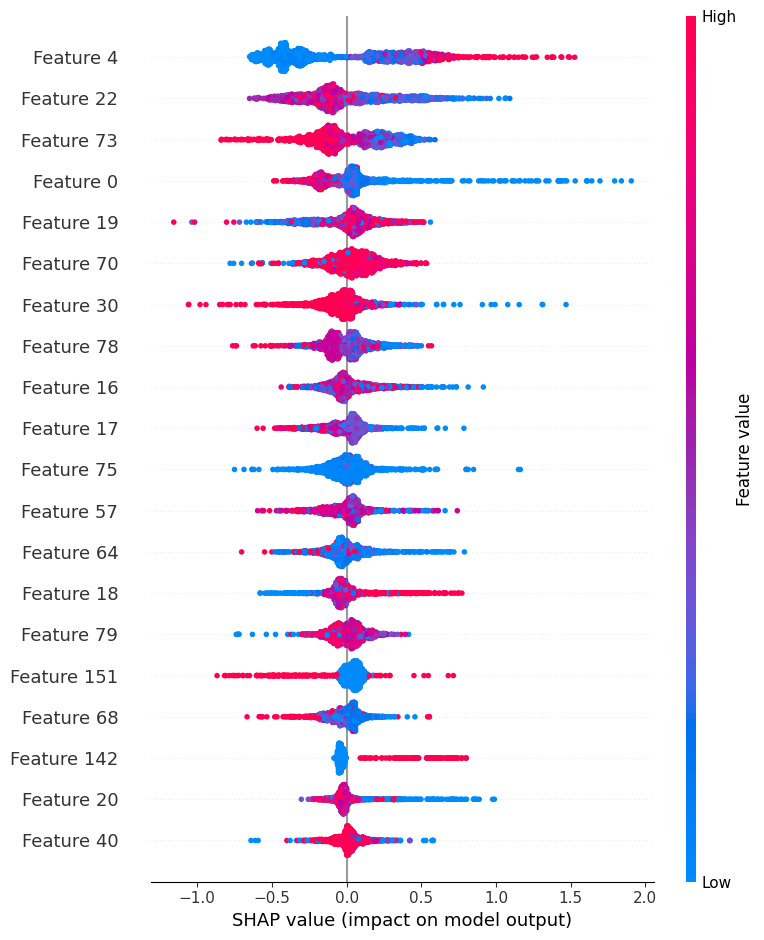

In [52]:
explicar_modelo(pipeline, X_test)

#### **4.3 - Tratamiento de la problemática 1: Fairness**

#### **5. Experimentos y Resultados**

In [53]:
def optimizar_modelo(nombre_modelo, estimador, param_grid, preprocessor, X_train, y_train):
    """
    Función maestra para ejecutar GridSearchCV, extraer las métricas multivariables
    y devolver el mejor modelo, el Top 10 en DataFrame y el resumen del ganador
    """
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', estimador)
    ])
    
    scoring_metrics = {
        'AUC': 'roc_auc', 'Accuracy': 'accuracy',
        'F1': 'f1', 'Precision': 'precision', 'Recall': 'recall'
    }
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=scoring_metrics,
        refit='AUC',
        n_jobs=-1,
        verbose=1
    )
    
    print(f'\nIniciando optimización para: {nombre_modelo}')
    grid_search.fit(X_train, y_train)
    
    print(f'\nMejor {nombre_modelo}')
    print(f'AUC-ROC Máximo: {grid_search.best_score_:.4f}')
    
    resultados = grid_search.cv_results_
    df_resultados = pd.DataFrame(resultados['params'])
    df_resultados.columns = [col.replace('classifier__', '') for col in df_resultados.columns]
    
    df_resultados['AUC-ROC'] = resultados['mean_test_AUC']
    df_resultados['Accuracy'] = resultados['mean_test_Accuracy']
    df_resultados['F1-Score'] = resultados['mean_test_F1']
    df_resultados['Precision'] = resultados['mean_test_Precision']
    df_resultados['Recall'] = resultados['mean_test_Recall']
    
    df_top10 = df_resultados.sort_values(by='AUC-ROC', ascending=False).head(10).reset_index(drop=True)
    
    idx_ganador = grid_search.best_index_
    resumen_ganador = {
        'Modelo': nombre_modelo,
        'AUC-ROC': resultados['mean_test_AUC'][idx_ganador],
        'Accuracy': resultados['mean_test_Accuracy'][idx_ganador],
        'F1-Score': resultados['mean_test_F1'][idx_ganador],
        'Precision': resultados['mean_test_Precision'][idx_ganador],
        'Recall': resultados['mean_test_Recall'][idx_ganador],
        'Hiperparámetros': str(grid_search.best_params_).replace('classifier__', '')
    }
    
    return grid_search.best_estimator_, df_top10, resumen_ganador

### Regresión Logística

In [54]:
param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100], # Inversa de la regularización
    'classifier__penalty': ['l2'],                   # Penalización Ridge
    'classifier__class_weight': [None, 'balanced']   # Balanceo de clases automático
}

mejor_modelo_lr, df_top10_lr, resumen_lr = optimizar_modelo(
    nombre_modelo="Regresión Logística",
    estimador=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid_lr,
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train
)

# Mostrar resultados
print("\nTOP 10")
display(df_top10_lr)


Iniciando optimización para: Regresión Logística
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejor Regresión Logística
AUC-ROC Máximo: 0.7432

TOP 10


,C,class_weight,penalty,AUC-ROC,Accuracy,F1-Score,Precision,Recall
0,0.10,NaN,l2,0.743197,0.687440,0.630860,0.683568,0.586178
1,0.10,balanced,l2,0.743065,0.684890,0.652058,0.656859,0.647687
2,0.01,NaN,l2,0.742876,0.683504,0.621882,0.682639,0.571446
3,1.00,NaN,l2,0.742791,0.683966,0.627070,0.678508,0.583123
4,0.01,balanced,l2,0.742720,0.685819,0.648672,0.661701,0.636511
5,1.00,balanced,l2,0.742648,0.680026,0.647260,0.650698,0.644129
6,10.00,NaN,l2,0.741009,0.683503,0.625640,0.678864,0.580587
7,10.00,balanced,l2,0.740976,0.679331,0.644355,0.651674,0.637518
8,100.00,NaN,l2,0.740405,0.682576,0.623936,0.678282,0.578042
9,100.00,balanced,l2,0.740290,0.678405,0.642758,0.651091,0.634976


### Árbol de Decisión

In [55]:
param_grid_dt = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [2, 3, 4, 5, 7, None],
    'classifier__min_samples_split': [2, 10, 20, 50],
    'classifier__min_samples_leaf': [1, 5, 10, 20],
    'classifier__class_weight': [None, 'balanced']
}

mejor_modelo_dt, df_top10_dt, resumen_dt = optimizar_modelo(
    nombre_modelo="Árbol de Decisión",
    estimador=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train
)

print("\nTOP 10")
display(df_top10_dt)


Iniciando optimización para: Árbol de Decisión
Fitting 5 folds for each of 384 candidates, totalling 1920 fits

Mejor Árbol de Decisión
AUC-ROC Máximo: 0.7295

TOP 10


,class_weight,criterion,max_depth,min_samples_leaf,min_samples_split,AUC-ROC,Accuracy,F1-Score,Precision,Recall
0,balanced,entropy,4.0,10,2,0.729509,0.682341,0.626741,0.679173,0.586201
1,balanced,entropy,4.0,10,10,0.729509,0.682341,0.626741,0.679173,0.586201
2,balanced,entropy,4.0,10,20,0.729509,0.682341,0.626741,0.679173,0.586201
3,balanced,entropy,4.0,10,50,0.729337,0.682341,0.626741,0.679173,0.586201
4,balanced,entropy,4.0,1,20,0.728200,0.682341,0.631059,0.674681,0.597399
5,balanced,entropy,4.0,5,20,0.728168,0.682341,0.631059,0.674681,0.597399
6,balanced,entropy,4.0,1,10,0.728087,0.682341,0.631059,0.674681,0.597399
7,balanced,entropy,4.0,1,2,0.728087,0.682341,0.631059,0.674681,0.597399
8,balanced,entropy,4.0,5,10,0.728055,0.682341,0.631059,0.674681,0.597399
9,balanced,entropy,4.0,5,2,0.728055,0.682341,0.631059,0.674681,0.597399


### Random Forest

In [56]:
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [5, 7, 10, 15, None],
    'classifier__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 5],
    'classifier__class_weight': [None, 'balanced', 'balanced_subsample']
}

mejor_modelo_rf, df_top10_rf, resumen_rf = optimizar_modelo(
    nombre_modelo='Random Forest',
    estimador=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train
)

print('\nTOP 10')
display(df_top10_rf)


Iniciando optimización para: Random Forest
Fitting 5 folds for each of 2700 candidates, totalling 13500 fits

Mejor Random Forest
AUC-ROC Máximo: 0.7485

TOP 10


,class_weight,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,AUC-ROC,Accuracy,F1-Score,Precision,Recall
0,NaN,5.0,0.7,5,5,100,0.748491,0.695550,0.641103,0.693163,0.596865
1,NaN,5.0,0.7,5,10,100,0.748491,0.695550,0.641103,0.693163,0.596865
2,NaN,5.0,0.7,5,2,100,0.748491,0.695550,0.641103,0.693163,0.596865
3,NaN,5.0,0.7,2,5,100,0.748351,0.694390,0.639738,0.692293,0.595340
4,NaN,5.0,0.3,5,10,100,0.748340,0.697171,0.644341,0.693933,0.601948
5,NaN,5.0,0.3,5,5,100,0.748340,0.697171,0.644341,0.693933,0.601948
6,NaN,5.0,0.3,5,2,100,0.748340,0.697171,0.644341,0.693933,0.601948
7,NaN,5.0,0.7,2,2,100,0.748185,0.695086,0.641208,0.692340,0.597884
8,NaN,5.0,0.7,2,10,100,0.748162,0.695317,0.641179,0.692776,0.597373
9,NaN,5.0,0.7,1,5,100,0.748126,0.693233,0.638830,0.690077,0.595341


### SVM

In [57]:
param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__class_weight': [None, 'balanced']
}

mejor_modelo_svm, df_top10_svm, resumen_svm = optimizar_modelo(
    nombre_modelo="SVM",
    estimador=SVC(probability=True, random_state=42),
    param_grid=param_grid_svm,
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train
)

print("\nTOP 10")
display(df_top10_svm)


Iniciando optimización para: SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejor SVM
AUC-ROC Máximo: 0.7386

TOP 10


,C,class_weight,kernel,AUC-ROC,Accuracy,F1-Score,Precision,Recall
0,0.1,balanced,linear,0.738579,0.682344,0.640737,0.661451,0.621765
1,0.1,NaN,linear,0.736041,0.685359,0.621835,0.687339,0.568397
2,10.0,balanced,rbf,0.734672,0.686285,0.638642,0.672187,0.609062
3,1.0,balanced,linear,0.734482,0.679101,0.638925,0.655886,0.623284
4,1.0,NaN,linear,0.733494,0.685822,0.623322,0.686892,0.570933
5,10.0,NaN,rbf,0.733484,0.679799,0.605957,0.689553,0.541463
6,10.0,balanced,linear,0.731504,0.675393,0.634929,0.651559,0.619726
7,10.0,NaN,linear,0.730584,0.683737,0.618300,0.686984,0.562805
8,1.0,balanced,rbf,0.728570,0.675629,0.589766,0.695598,0.512996
9,1.0,NaN,rbf,0.726793,0.657558,0.522490,0.714941,0.412849


### XGBoost

In [58]:
# === XGBoost con Optuna (Bayesian Optimization) ===
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0, 5.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 3.0),
    }
    
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(**params, random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print('Optimizando XGBoost con Optuna (500 trials)...')
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=500, show_progress_bar=True)

print(f'\nMejor XGBoost AUC-ROC: {study_xgb.best_value:.4f}')
print(f'Mejores params: {study_xgb.best_params}')

# Entrenar el mejor modelo
mejor_modelo_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(**study_xgb.best_params, random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
mejor_modelo_xgb.fit(X_train, y_train)

resumen_xgb = {
    'Modelo': 'XGBoost (Optuna)',
    'AUC-ROC': study_xgb.best_value,
    'Accuracy': np.nan, 'F1-Score': np.nan, 'Precision': np.nan, 'Recall': np.nan,
    'Hiperparámetros': str(study_xgb.best_params)
}
for metric_name, scorer in [('Accuracy','accuracy'),('F1-Score','f1'),('Precision','precision'),('Recall','recall')]:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    resumen_xgb[metric_name] = cross_val_score(mejor_modelo_xgb, X_train, y_train, cv=cv, scoring=scorer, n_jobs=-1).mean()

Optimizando XGBoost con Optuna (500 trials)...


  0%|          | 0/500 [00:00<?, ?it/s]


Mejor XGBoost AUC-ROC: 0.7594
Mejores params: {'n_estimators': 958, 'max_depth': 3, 'learning_rate': 0.02112312801437094, 'subsample': 0.9056584631011442, 'colsample_bytree': 0.30077661274110906, 'min_child_weight': 1, 'reg_alpha': 2.181049117291303e-08, 'reg_lambda': 1.4184091929443606e-06, 'gamma': 3.646480823212535, 'scale_pos_weight': 1.1543731106765376}


### LightGBM

In [59]:
# === LightGBM con Optuna (Bayesian Optimization) ===
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 200),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 3.0),
    }
    
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(**params, random_state=42, verbose=-1))
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print('Optimizando LightGBM con Optuna (500 trials)...')
study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=500, show_progress_bar=True)

print(f'\nMejor LightGBM AUC-ROC: {study_lgbm.best_value:.4f}')
print(f'Mejores params: {study_lgbm.best_params}')

mejor_modelo_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(**study_lgbm.best_params, random_state=42, verbose=-1))
])
mejor_modelo_lgbm.fit(X_train, y_train)

resumen_lgbm = {
    'Modelo': 'LightGBM (Optuna)',
    'AUC-ROC': study_lgbm.best_value,
    'Accuracy': np.nan, 'F1-Score': np.nan, 'Precision': np.nan, 'Recall': np.nan,
    'Hiperparámetros': str(study_lgbm.best_params)
}
for metric_name, scorer in [('Accuracy','accuracy'),('F1-Score','f1'),('Precision','precision'),('Recall','recall')]:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    resumen_lgbm[metric_name] = cross_val_score(mejor_modelo_lgbm, X_train, y_train, cv=cv, scoring=scorer, n_jobs=-1).mean()

Optimizando LightGBM con Optuna (500 trials)...


  0%|          | 0/500 [00:00<?, ?it/s]


Mejor LightGBM AUC-ROC: 0.7565
Mejores params: {'n_estimators': 774, 'max_depth': 4, 'learning_rate': 0.007000774338328294, 'num_leaves': 61, 'min_child_samples': 13, 'subsample': 0.9869925514686586, 'colsample_bytree': 0.5741113932269354, 'reg_alpha': 5.90446585680001e-08, 'reg_lambda': 3.433362580490216e-06, 'min_split_gain': 0.6722298436260519, 'scale_pos_weight': 1.2386676180098513}


### Gradient Boosting

In [60]:
# === Gradient Boosting con Optuna ===
def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7, 0.9]),
    }
    
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(**params, random_state=42))
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print('Optimizando Gradient Boosting con Optuna (300 trials)...')
study_gb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_gb.optimize(objective_gb, n_trials=300, show_progress_bar=True)

print(f'\nMejor Gradient Boosting AUC-ROC: {study_gb.best_value:.4f}')
print(f'Mejores params: {study_gb.best_params}')

mejor_modelo_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(**study_gb.best_params, random_state=42))
])
mejor_modelo_gb.fit(X_train, y_train)

resumen_gb = {
    'Modelo': 'Gradient Boosting (Optuna)',
    'AUC-ROC': study_gb.best_value,
    'Accuracy': np.nan, 'F1-Score': np.nan, 'Precision': np.nan, 'Recall': np.nan,
    'Hiperparámetros': str(study_gb.best_params)
}
for metric_name, scorer in [('Accuracy','accuracy'),('F1-Score','f1'),('Precision','precision'),('Recall','recall')]:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    resumen_gb[metric_name] = cross_val_score(mejor_modelo_gb, X_train, y_train, cv=cv, scoring=scorer, n_jobs=-1).mean()

Optimizando Gradient Boosting con Optuna (300 trials)...


  0%|          | 0/300 [00:00<?, ?it/s]


Mejor Gradient Boosting AUC-ROC: 0.7590
Mejores params: {'n_estimators': 722, 'max_depth': 3, 'learning_rate': 0.009964010261287584, 'subsample': 0.8313426839735223, 'min_samples_split': 46, 'min_samples_leaf': 4, 'max_features': 0.7}


### Stacking Ensemble

In [61]:
# === Stacking Ensemble con Calibración ===
# Calibramos los modelos base para mejorar las probabilidades del meta-learner
stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', CalibratedClassifierCV(mejor_modelo_xgb.named_steps['classifier'], cv=3, method='isotonic')),
        ('rf', mejor_modelo_rf.named_steps['classifier']),
        ('lgbm', CalibratedClassifierCV(mejor_modelo_lgbm.named_steps['classifier'], cv=3, method='isotonic')),
        ('gb', CalibratedClassifierCV(mejor_modelo_gb.named_steps['classifier'], cv=3, method='isotonic')),
        ('lr', mejor_modelo_lr.named_steps['classifier']),
        ('svm', mejor_modelo_svm.named_steps['classifier']),
    ],
    final_estimator=LogisticRegression(max_iter=1000, C=0.1, random_state=42),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    n_jobs=-1
)

pipeline_stacking = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', stacking_clf)
])

print('Entrenando Stacking Ensemble con calibración...')
pipeline_stacking.fit(X_train, y_train)

resumen_stacking = {
    'Modelo': 'Stacking (Calibrado)',
    'AUC-ROC': np.nan, 'Accuracy': np.nan, 'F1-Score': np.nan,
    'Precision': np.nan, 'Recall': np.nan,
    'Hiperparámetros': 'XGB+RF+LGBM+GB+LR+SVM -> LR meta (isotonic calibration)'
}

for metric_name, scorer in [('AUC-ROC','roc_auc'),('Accuracy','accuracy'),('F1-Score','f1'),('Precision','precision'),('Recall','recall')]:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline_stacking, X_train, y_train, cv=cv, scoring=scorer, n_jobs=-1)
    resumen_stacking[metric_name] = scores.mean()

print(f'\nStacking (Calibrado) AUC-ROC (CV): {resumen_stacking["AUC-ROC"]:.4f}')
print(f'Stacking (Calibrado) Accuracy (CV): {resumen_stacking["Accuracy"]:.4f}')
print(f'Stacking (Calibrado) F1-Score (CV): {resumen_stacking["F1-Score"]:.4f}')

Entrenando Stacking Ensemble con calibración...


[17:12:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[17:12:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[17:12:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[17:12:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[17:12:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[17:12:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[17:12:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[17:12:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" }


Stacking (Calibrado) AUC-ROC (CV): 0.7575
Stacking (Calibrado) Accuracy (CV): 0.6981
Stacking (Calibrado) F1-Score (CV): 0.6493


In [62]:
lista_resumenes = [resumen_lr, resumen_dt, resumen_rf, resumen_svm, resumen_xgb, resumen_lgbm, resumen_gb, resumen_stacking]

df_comparativa_final = pd.DataFrame(lista_resumenes)
df_comparativa_final = df_comparativa_final.sort_values(by='AUC-ROC', ascending=False).reset_index(drop=True)

print('\n' + '='*80)
print('COMPARATIVA FINAL DE TODOS LOS MODELOS (con PolynomialFeatures + Optuna)')
print('='*80)
display(df_comparativa_final.drop(columns=['Hiperparámetros']))

print('\nHiperparámetros Ganadores:')
for i, row in df_comparativa_final.iterrows():
    print(f"{row['Modelo']}: {row['Hiperparámetros']}")

print(f'\nMejor modelo: {df_comparativa_final.iloc[0]["Modelo"]} con AUC-ROC: {df_comparativa_final.iloc[0]["AUC-ROC"]:.4f}')


COMPARATIVA FINAL DE TODOS LOS MODELOS (con PolynomialFeatures + Optuna)


,Modelo,AUC-ROC,Accuracy,F1-Score,Precision,Recall
0,XGBoost (Optuna),0.759398,0.697870,0.662240,0.674978,0.650765
1,Gradient Boosting (Optuna),0.758969,0.701345,0.649819,0.698036,0.608564
2,Stacking (Calibrado),0.757465,0.698100,0.649330,0.690044,0.613641
3,LightGBM (Optuna),0.756542,0.694856,0.665772,0.665192,0.667544
4,Random Forest,0.748491,0.695550,0.641103,0.693163,0.596865
5,Regresión Logística,0.743197,0.687440,0.630860,0.683568,0.586178
6,SVM,0.738579,0.682344,0.640737,0.661451,0.621765
7,Árbol de Decisión,0.729509,0.682341,0.626741,0.679173,0.586201



Hiperparámetros Ganadores:
XGBoost (Optuna): {'n_estimators': 958, 'max_depth': 3, 'learning_rate': 0.02112312801437094, 'subsample': 0.9056584631011442, 'colsample_bytree': 0.30077661274110906, 'min_child_weight': 1, 'reg_alpha': 2.181049117291303e-08, 'reg_lambda': 1.4184091929443606e-06, 'gamma': 3.646480823212535, 'scale_pos_weight': 1.1543731106765376}
Gradient Boosting (Optuna): {'n_estimators': 722, 'max_depth': 3, 'learning_rate': 0.009964010261287584, 'subsample': 0.8313426839735223, 'min_samples_split': 46, 'min_samples_leaf': 4, 'max_features': 0.7}
Stacking (Calibrado): XGB+RF+LGBM+GB+LR+SVM -> LR meta (isotonic calibration)
LightGBM (Optuna): {'n_estimators': 774, 'max_depth': 4, 'learning_rate': 0.007000774338328294, 'num_leaves': 61, 'min_child_samples': 13, 'subsample': 0.9869925514686586, 'colsample_bytree': 0.5741113932269354, 'reg_alpha': 5.90446585680001e-08, 'reg_lambda': 3.433362580490216e-06, 'min_split_gain': 0.6722298436260519, 'scale_pos_weight': 1.2386676180

In [63]:
# Evaluación final en TEST SET
print('='*80)
print('EVALUACIÓN EN TEST SET')
print('='*80)

modelos_finales = {
    'Logistic Regression': mejor_modelo_lr,
    'Decision Tree': mejor_modelo_dt,
    'Random Forest': mejor_modelo_rf,
    'SVM': mejor_modelo_svm,
    'XGBoost (Optuna)': mejor_modelo_xgb,
    'LightGBM (Optuna)': mejor_modelo_lgbm,
    'Gradient Boosting (Optuna)': mejor_modelo_gb,
    'Stacking (Calibrado)': pipeline_stacking,
}

resultados_test = []
for nombre, modelo in modelos_finales.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    resultados_test.append({
        'Modelo': nombre,
        'Test AUC': roc_auc_score(y_test, y_proba),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test F1': f1_score(y_test, y_pred),
    })

df_test = pd.DataFrame(resultados_test).sort_values('Test AUC', ascending=False).reset_index(drop=True)
display(df_test)

print(f'\nMejor en test: {df_test.iloc[0]["Modelo"]} con AUC: {df_test.iloc[0]["Test AUC"]:.4f}')

EVALUACIÓN EN TEST SET


,Modelo,Test AUC,Test Accuracy,Test F1
0,Stacking (Calibrado),0.733934,0.685575,0.638958
1,XGBoost (Optuna),0.731382,0.680713,0.647585
2,LightGBM (Optuna),0.729433,0.674770,0.647953
3,Gradient Boosting (Optuna),0.728934,0.675311,0.625078
4,Logistic Regression,0.728126,0.675851,0.617347
5,Random Forest,0.722360,0.669368,0.615094
6,SVM,0.719974,0.676391,0.634979
7,Decision Tree,0.702944,0.661804,0.645527



Mejor en test: Stacking (Calibrado) con AUC: 0.7339
